In [2]:
from meteostat import Point, Daily,Stations
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [1]:
#stations = Stations()
#stations = stations.nearby(3.1390 , 101.6869)
#stations = stations.fetch(11)
#stations

# Obtains all available stations from Malaysia as trying to get stations directly from "Malaysia" gave no rows back.

In [4]:
Penang  = Point(5.3000, 100.2667)
start   = datetime(2010,1,1)
end     = datetime(2025,12,31)

data = Daily(Penang, start,end)
data = data.fetch()
data.head()

# we're obtaining 15 years worth of data

In [13]:
data.to_csv("Penang_15year_weather_info.csv")

In [5]:
df =pd.read_csv(r"C:\Users\leemi\revisionsw\Portfolio\Penang_15year_weather_info.csv", low_memory = True)
# Filesize was a little too big, low_memory was done as an insurance.

In [6]:
df2 = df.drop(columns = ["snow","wdir","wpgt","tsun","pres"])
# Removing unnecessary columns(populated mostly with NaN). Pres(Sea Level Pressure) has data but it is 
# unlikely to be used.

In [7]:
df3 = df2.interpolate(limit=3)

In [8]:
df4 = df3.rename(columns={"time" : "date"})

In [9]:
df4.set_index("date",inplace= True)
df4.index = pd.to_datetime(df4.index)
df4.index

DatetimeIndex(['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04',
               '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08',
               '2010-01-09', '2010-01-10',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-20',
               '2025-12-21', '2025-12-22', '2025-12-23', '2025-12-24',
               '2025-12-25', '2025-12-26'],
              dtype='datetime64[ns]', name='date', length=5839, freq=None)

In [9]:
df4.to_parquet("15year_base.parquet")

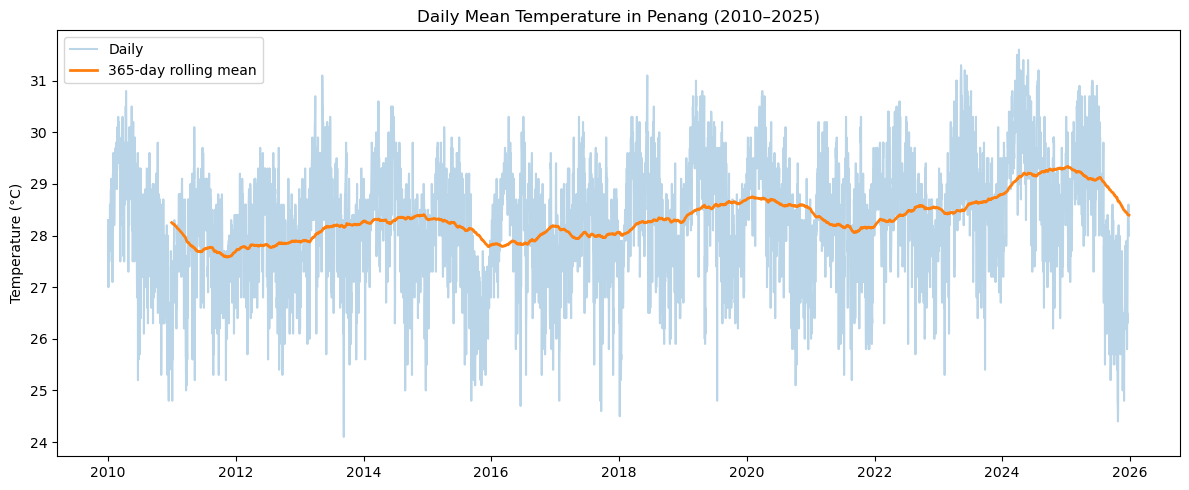

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(df4.index, df4["tavg"], alpha=0.3, label="Daily")
plt.plot(
    df4.index,
    df4["tavg"].rolling(365).mean(),
    linewidth=2,
    label="365-day rolling mean"
)

plt.title("Daily Mean Temperature in Penang (2010–2025)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()
# haha, the dates are all smushed together because of the amount of rows(15x365),
# interesting enough the avg temperature dips quite drastically at the end. 

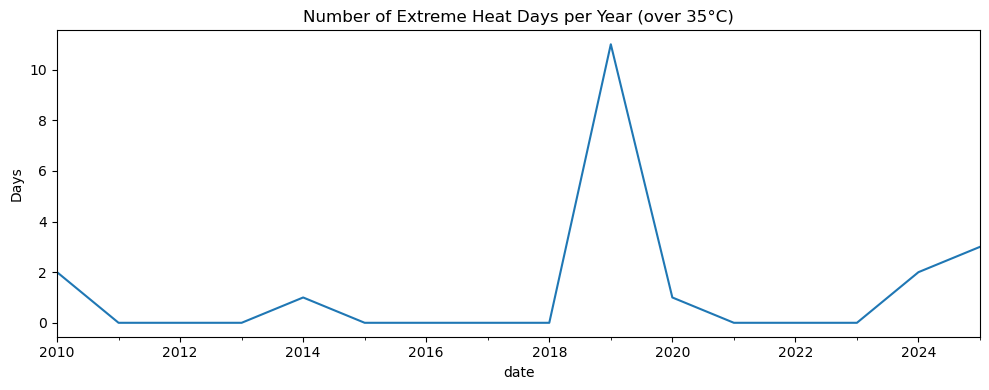

In [11]:
df4["extreme_heat"] = df4["tmax"] > 35

extreme_per_year = df4["extreme_heat"].resample("YE").sum()

plt.figure(figsize=(10, 4))
extreme_per_year.plot()

plt.title("Number of Extreme Heat Days per Year (over 35°C)")
plt.ylabel("Days")
plt.tight_layout()
plt.show()
# hmmm this doesn't really effectivly show the data... the only thing we can obtain for the data is
# that 2019 is one particularly hot year... hmmm why was it so hot anyways?

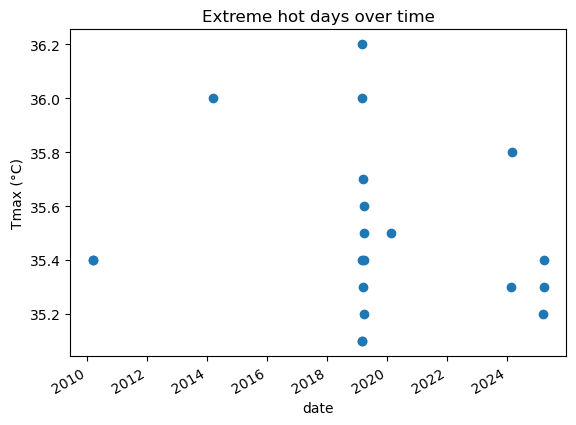

In [12]:
df4.loc[df4["tmax"] > 35, "tmax"].plot(style="o")
plt.title("Extreme hot days over time")
plt.ylabel("Tmax (°C)")
plt.show()
# The days between 2019 and 2020 has the most potential to be considered level 1 caution of 
# heatwaves(consecutive 3 days over 35°C).
# Honestly i don't really know if i'm even reading this right....I'm not used to this type of graph

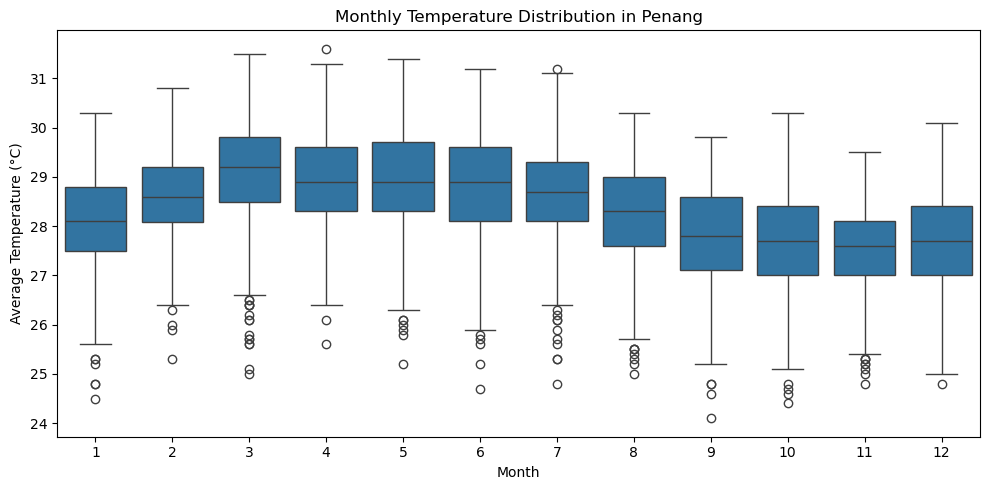

In [13]:
df4["month"] = df4.index.month
plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="tavg", data=df4)

plt.title("Monthly Temperature Distribution in Penang")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

# hmmm this shows the avarage temperatures of months for the past 15 years....might not be an effective way to show data, as global warming
# might change the tempereature across the years....I wonder if doing this as a line chart without categorizing them under months would show better 
# data...

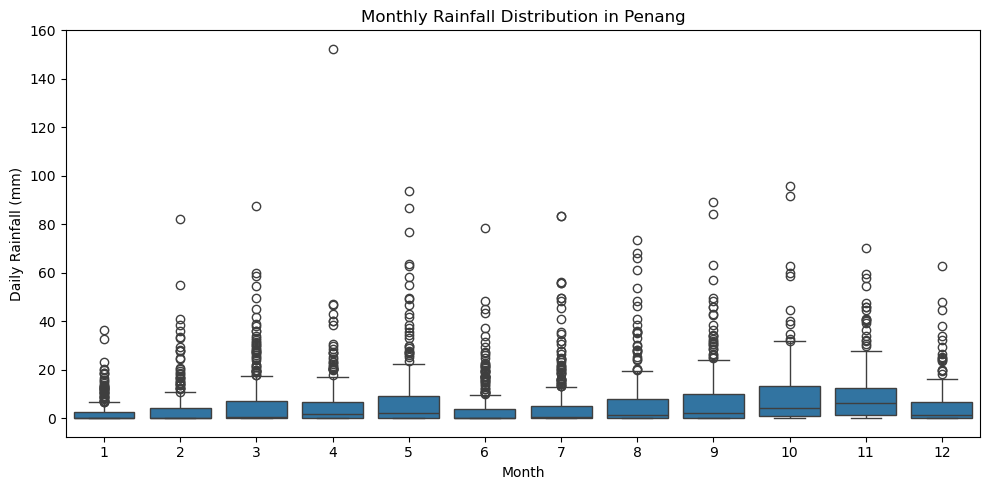

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="prcp", data=df4)

plt.title("Monthly Rainfall Distribution in Penang")
plt.xlabel("Month")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.show()

# Same problem as above....it shows the rainfall distribution but like 15 years of data is compressed into months
# .... is this really a good way to show data?
# same problem global warming might play a big role causing the amount of rain to either decrease/increase depending on the increasing of
# global warming... but like global warming might also not affect this as much as I thought? hmmm should check again. Maybe instead of "daily" I 
# should make them into months so that I'd get 12x 15 rows instead of 365 X 15. Bar graph would be great, allows me to see when the par peaks at 
# each year,identifing the "monsoone seasons" 

# hmm apparently the monsoon season is between may to september, honestly it feels a little hard to look at the data here.....
# as a person who's not used to looking at the chart determining when the rain fall congregates to determine the monsoon season is impossible 
#I mean 

In [ ]:
# ugh maybe box plot really is the best way to see when the monsoon seasons come by?

In [27]:
dfpd.read_csv(r"C:\Users\leemi\revisionsw\Portfolio\monthly.csv")

,date,tavg,tmin,tmax,prcp,wspd,extreme_heat,month
0,2010-01-31,28.241935,25.116129,32.238710,1.403226,8.196774,0.000000,1.0
1,2010-02-28,29.367857,25.894643,33.567857,1.207143,8.264286,0.000000,2.0
2,2010-03-31,29.196774,25.670968,33.396774,5.683871,7.990323,0.064516,3.0
3,2010-04-30,29.176667,25.850000,32.853333,3.758333,6.676667,0.000000,4.0
4,2010-05-31,29.380645,26.062903,33.030645,7.117742,5.809677,0.000000,5.0
...,...,...,...,...,...,...,...,...
187,2025-08-31,27.545161,24.451613,30.661290,6.222581,6.470968,0.000000,8.0
188,2025-09-30,27.293333,24.333333,30.433333,6.190000,6.356667,0.000000,9.0
189,2025-10-31,26.609677,23.967742,29.980645,8.419355,5.851613,0.000000,10.0
190,2025-11-30,26.356667,23.966667,29.400000,9.063333,7.006667,0.000000,11.0


In [33]:
df21=df20.drop(columns=["extreme_heat","month"])
df21.set_index("date",inplace= True)

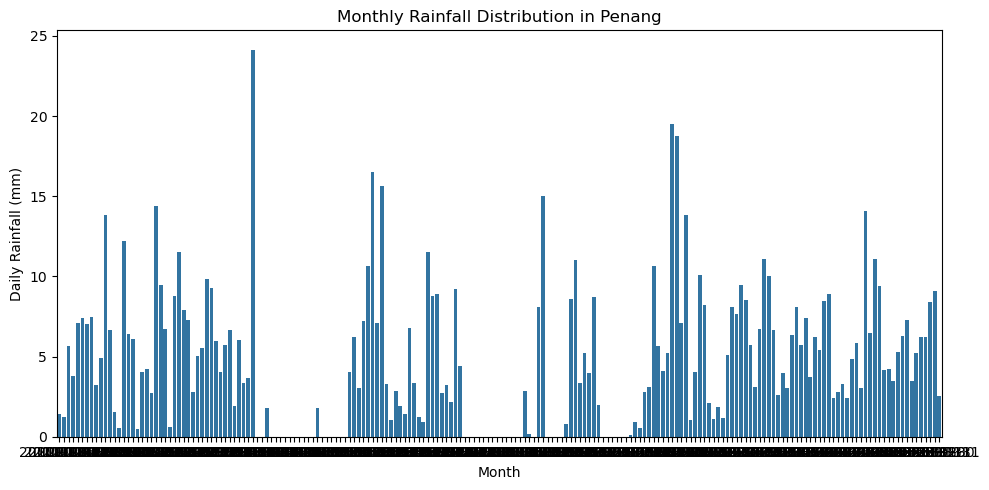

In [81]:
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=df21)

plt.title("Monthly Rainfall Distribution in Penang")
plt.xlabel("Month")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.show()
# this actually shows when the most rainfall is, but the problem is that there's way too much data,
# so clearer viewing of which particular months they are are hard....
# I'll have to check if there's other ways....

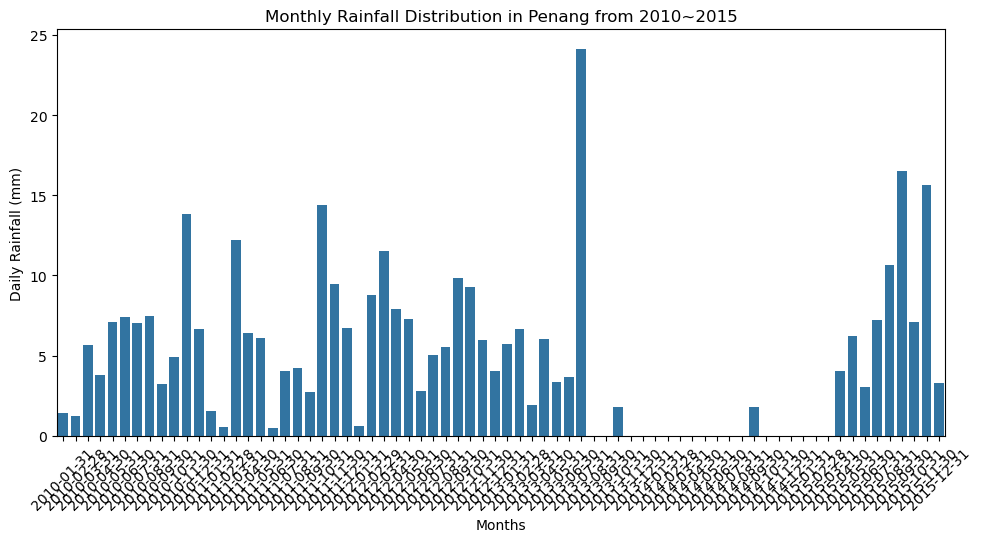

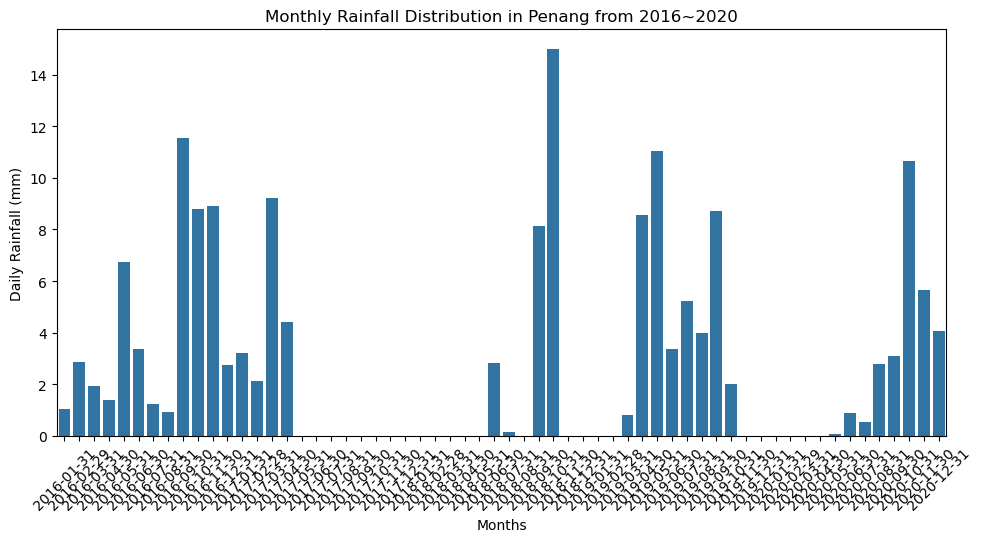

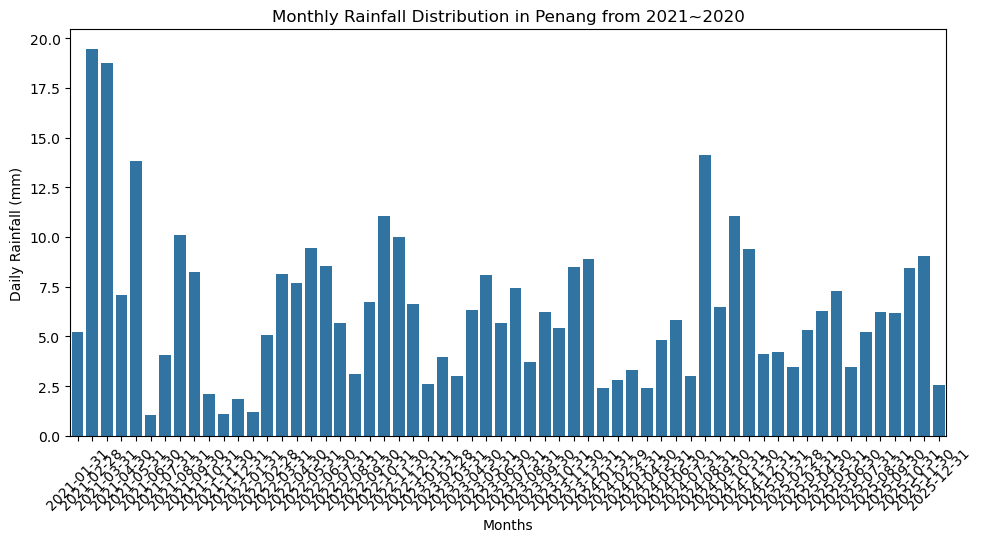

In [96]:
subset1 = df21.loc['2010':'2015']
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=subset1)

plt.title("Monthly Rainfall Distribution in Penang from 2010~2015")
plt.xlabel("Months")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

subset2 = df21.loc['2016':'2020']
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=subset2)

plt.title("Monthly Rainfall Distribution in Penang from 2016~2020")
plt.xlabel("Months")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

subset3 = df21.loc['2021':'2025']
plt.figure(figsize=(10, 5))
sns.barplot(x="date", y="prcp", data=subset3)

plt.title("Monthly Rainfall Distribution in Penang from 2021~2020")
plt.xlabel("Months")
plt.ylabel("Daily Rainfall (mm)")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

# looks better.....I wonder if there's a smaller code that can achieve the same results...
# or at least change the labelling/ period of the dates..... I know 
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
# does what I want but like the graph is UGLYYY!

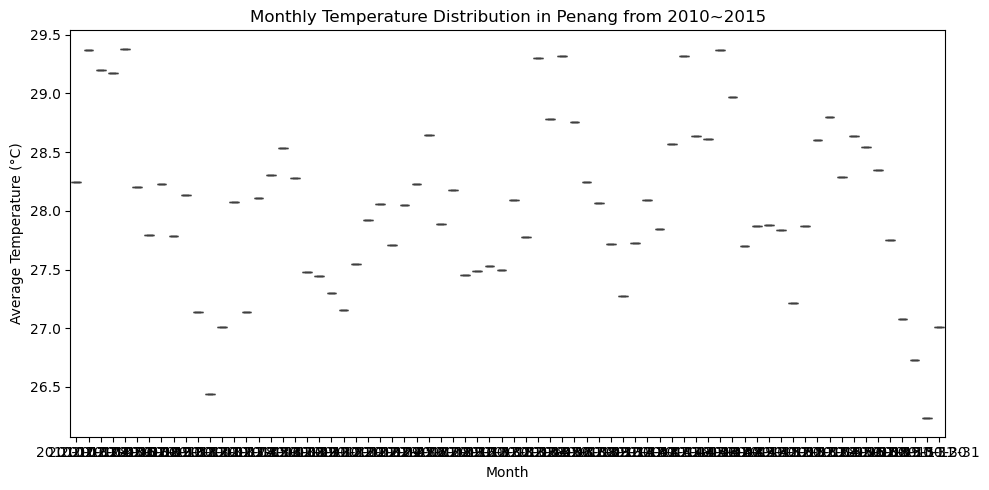

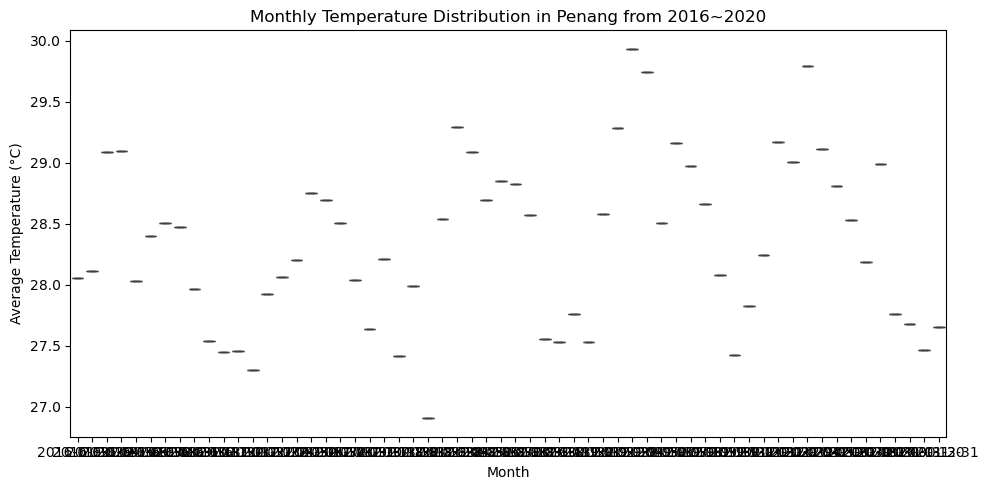

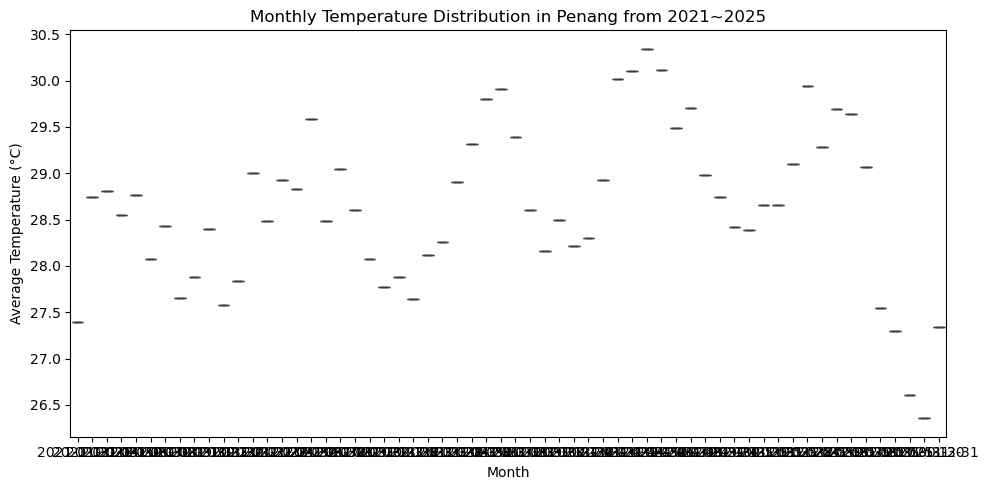

In [93]:
#let's try the temperature this time box plot style

plt.figure(figsize=(10, 5))
sns.boxplot(x="date", y="tavg", data=subset1)

plt.title("Monthly Temperature Distribution in Penang from 2010~2015")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="date", y="tavg", data=subset2)

plt.title("Monthly Temperature Distribution in Penang from 2016~2020")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="date", y="tavg", data=subset3)

plt.title("Monthly Temperature Distribution in Penang from 2021~2025")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()
#ugh 100% "no", is there a better way? 12X5= 60.... yeah this is still too much.... 

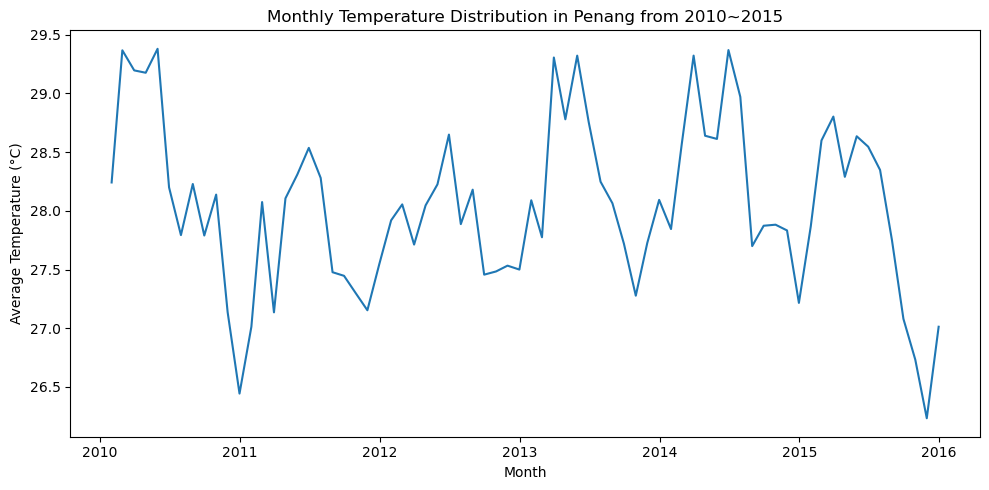

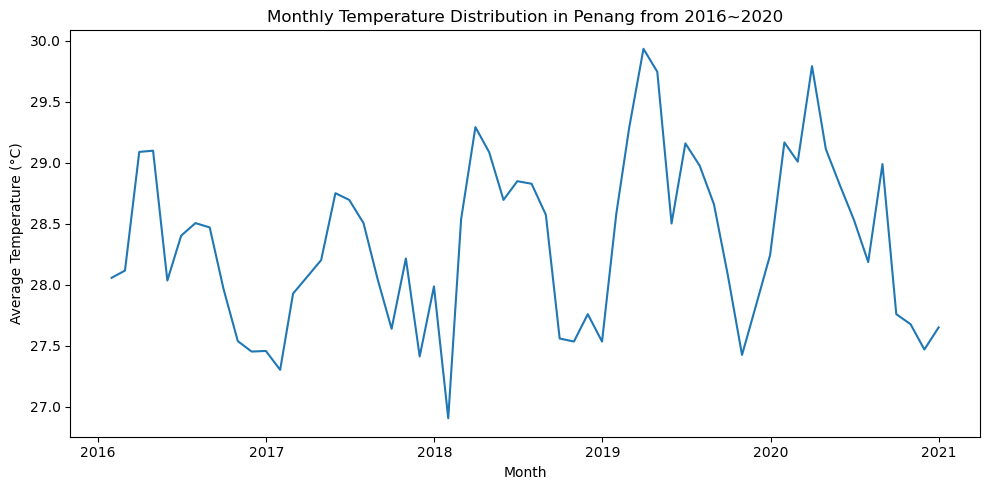

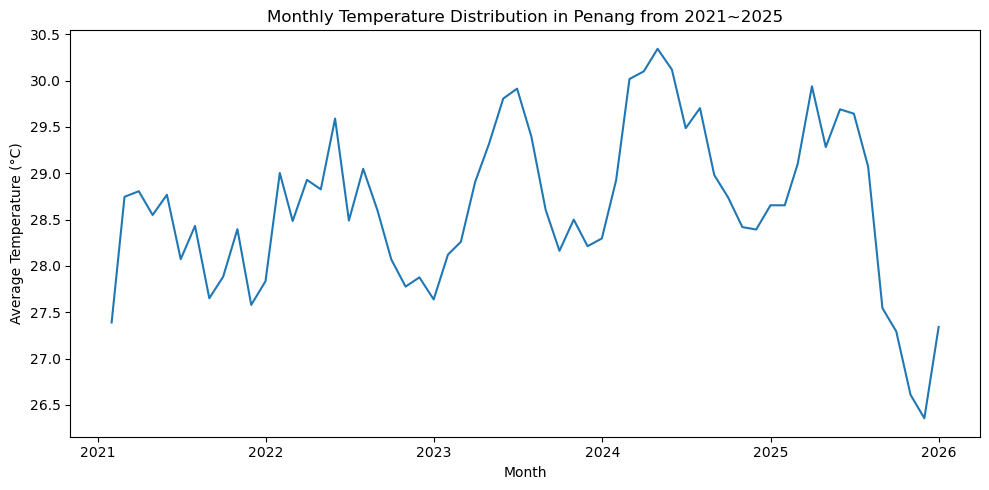

In [97]:
plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="tavg", data=subset1)

plt.title("Monthly Temperature Distribution in Penang from 2010~2015")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="tavg", data=subset2)

plt.title("Monthly Temperature Distribution in Penang from 2016~2020")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x="date", y="tavg", data=subset3)

plt.title("Monthly Temperature Distribution in Penang from 2021~2025")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()